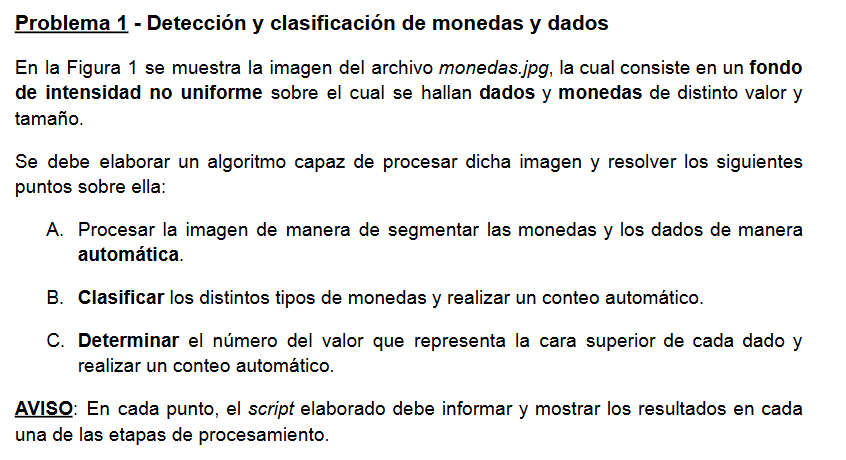

In [1]:
import cv2
import numpy as np
from matplotlib import pyplot as plt

# PARTE A

In [2]:
img = cv2.imread('img/monedas.jpg')

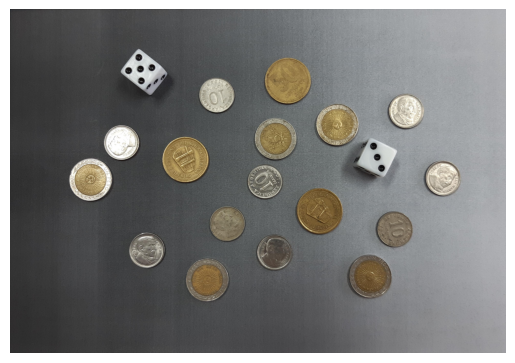

In [3]:
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.show()

In [4]:
img_gris = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

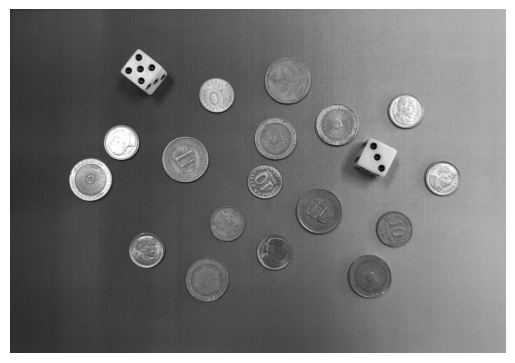

In [5]:
plt.imshow(img_gris, cmap='gray')
plt.axis('off')
plt.show()

In [6]:
# filtro gaussiano
img_gris_blur = cv2.GaussianBlur(img_gris, (9, 9), 2)

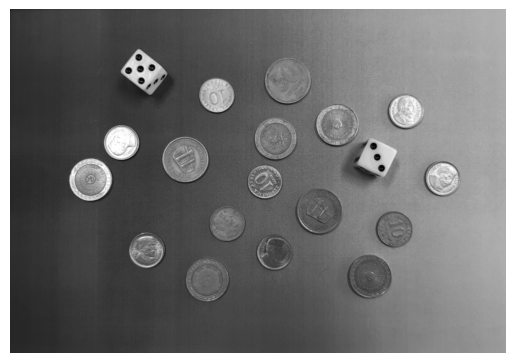

In [7]:
plt.imshow(img_gris_blur, cmap='gray')
plt.axis('off')
plt.show()

umbralado de la practica pdi_u3_segmentacion.py

con  cv2.threshold()

https://docs.opencv.org/4.x/d7/d1b/group__imgproc__misc.html#gae8a4a146d1ca78c626a53577199e9c57

100.0
uint8
[  0 255]


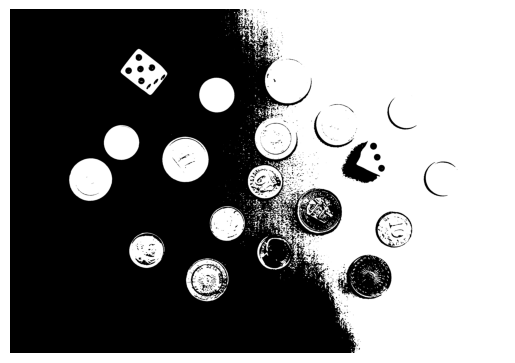

In [8]:
th_out, img_umbralado = cv2.threshold(img_gris_blur, thresh=100, maxval=255, type=cv2.THRESH_BINARY)
print(th_out)
print(img_umbralado.dtype)
print(np.unique(img_umbralado))
plt.imshow(img_umbralado, cmap='gray')
plt.axis('off')
plt.show()

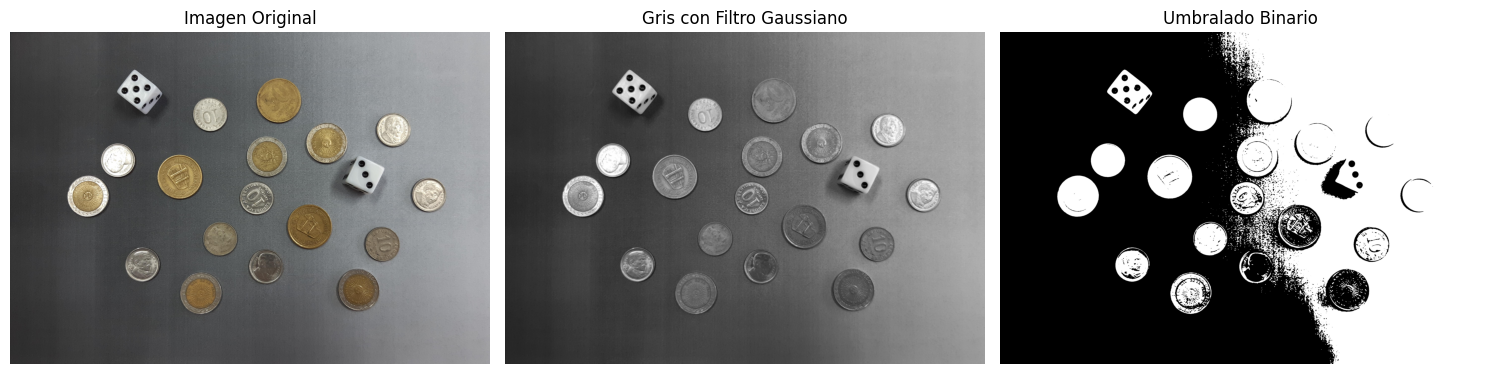

In [9]:
plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title('Imagen Original')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(img_gris_blur, cmap='gray')
plt.title('Gris con Filtro Gaussiano')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(img_umbralado, cmap='gray')
plt.title('Umbralado Binario')
plt.axis('off')

plt.tight_layout()
plt.show()


 cv2.adaptiveThreshold(

   imagen_fuente (grises),

   valor_maximo (255, blanco),

   metodo_adaptativo (cv2.ADAPTIVE_THRESH_GAUSSIAN_C -> mejor para iluminación variable),

   tipo_umbral (cv2.THRESH_BINARY_INV -> Invertido, queremos objetos blancos),

   tamano_bloque (ej. 31x31 píxeles, debe ser impar),
   
   C (constante a restar de la media, ajusta la sensibilidad)
 )

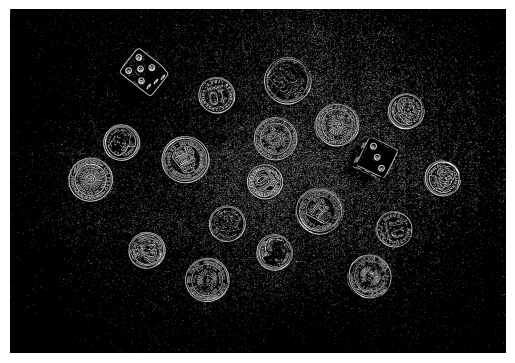

In [10]:
# hay que hacer umbralado local (vecinos)
img_umbralado_oscuro = cv2.adaptiveThreshold(
        img_gris_blur,
        255,
        cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
        cv2.THRESH_BINARY_INV,   # objetos oscuros
        11, # Tamaño del bloque (vecindario)
        2   # Constante C
    )

plt.imshow(img_umbralado_oscuro, cmap='gray')
plt.axis('off')
plt.show()

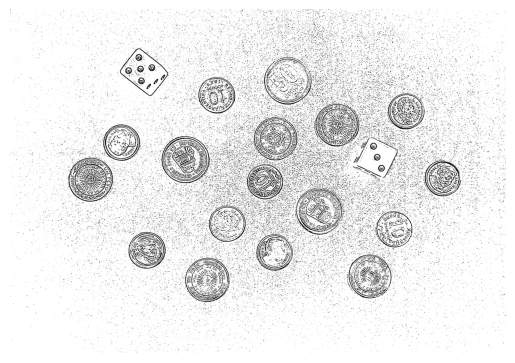

In [11]:
# hay que hacer umbralado local (vecinos)
img_umbralado_blancos = cv2.adaptiveThreshold(
        img_gris_blur,
        255,
        cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
        cv2.THRESH_BINARY,   # objetos blancos
        11, # Tamaño del bloque (vecindario)
        2   # Constante C
    )

plt.imshow(img_umbralado_blancos, cmap='gray')
plt.axis('off')
plt.show()

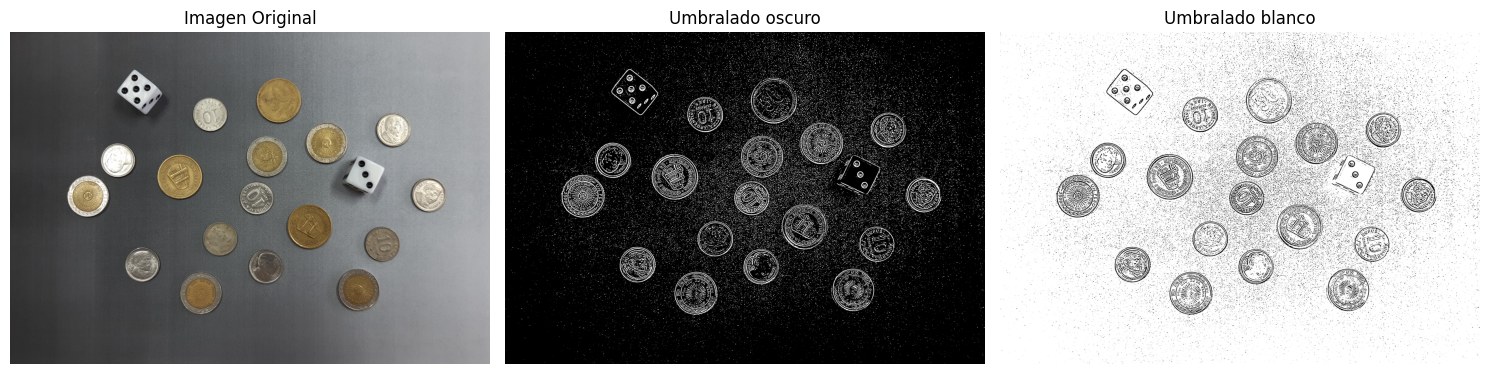

In [12]:
plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title('Imagen Original')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(img_umbralado_oscuro, cmap='gray')
plt.title('Umbralado oscuro')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(img_umbralado_blancos, cmap='gray')
plt.title('Umbralado blanco')
plt.axis('off')

plt.tight_layout()
plt.show()

In [13]:
# componentes conectadas
(num_labels, labels, stats, centroids) = cv2.connectedComponentsWithStats(
    img_umbralado_blancos,
    connectivity=8,
    ltype=cv2.CV_32S
)

In [14]:
copia_img = img.copy()

In [15]:
for i in range(1, num_labels):
    x = stats[i, cv2.CC_STAT_LEFT]
    y = stats[i, cv2.CC_STAT_TOP]
    w = stats[i, cv2.CC_STAT_WIDTH]
    h = stats[i, cv2.CC_STAT_HEIGHT]
    area = stats[i, cv2.CC_STAT_AREA]

    cv2.rectangle(copia_img, (x, y), (x + w, y + h), (0, 255, 0), 2)
    
    (cX, cY) = centroids[i]
    cv2.putText(copia_img, str(i), (int(cX) - 10, int(cY)), 
                cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 0, 255), 2)

print(f"Se encontraron {num_labels - 1} objetos.")

Se encontraron 251 objetos.


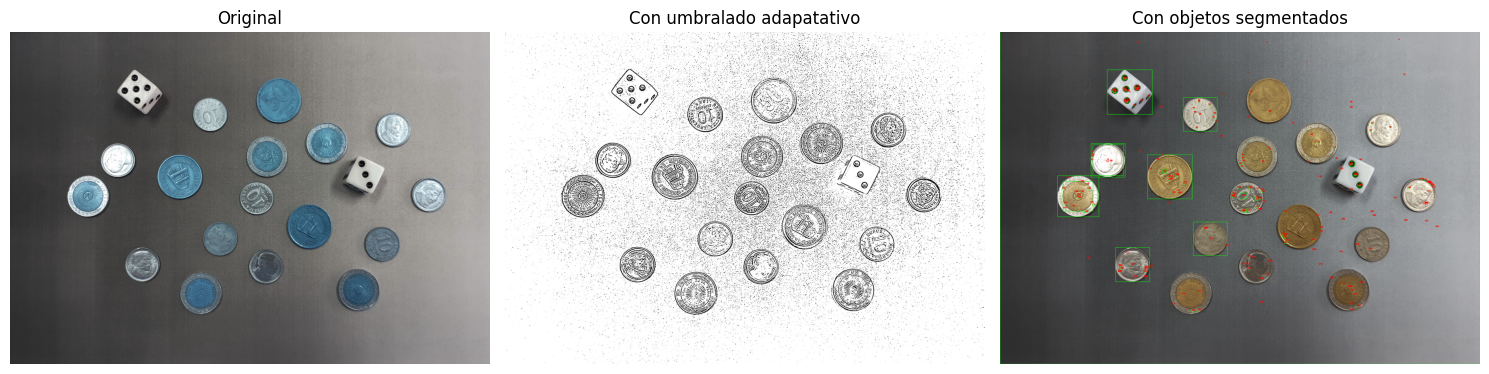

In [16]:
plt.figure(figsize=(15, 7))

plt.subplot(1, 3, 1)
plt.imshow(img, cmap='gray')
plt.title('Original')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(img_umbralado_blancos, cmap='gray')
plt.title('Con umbralado adapatativo')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(cv2.cvtColor(copia_img, cv2.COLOR_BGR2RGB))
plt.title('Con objetos segmentados')
plt.axis('off')

plt.tight_layout()
plt.show()

# probando con otro umbralado

tecnica top-hat (PI_U6_Morfologico_pt_grises.py)

In [82]:
img_color = cv2.imread('img/monedas.jpg')
gray = cv2.cvtColor(img_color, cv2.COLOR_BGR2GRAY)

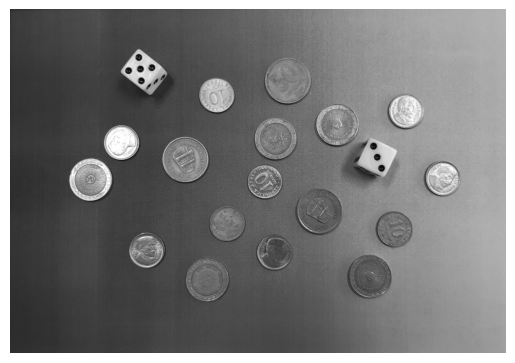

In [83]:
gray_blur = cv2.GaussianBlur(gray, (3, 3), 1)

plt.imshow(gray_blur, cmap='gray')
plt.axis('off')
plt.show()

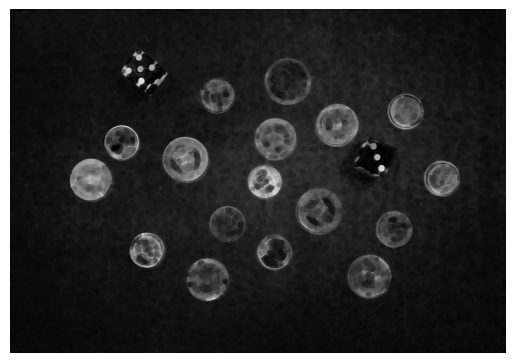

In [84]:
# Operaciones Top-Hat y Black-Hat
kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (35, 35))

# Top-Hat (objetos brillantes)
tophat = cv2.morphologyEx(gray_blur, cv2.MORPH_TOPHAT, kernel)

# Black-Hat (Objetos oscuros)
blackhat = cv2.morphologyEx(gray_blur, cv2.MORPH_BLACKHAT, kernel)

# combinar mascaras
mask = cv2.add(tophat, blackhat)

plt.imshow(mask, cmap='gray')
plt.axis('off')
plt.show()

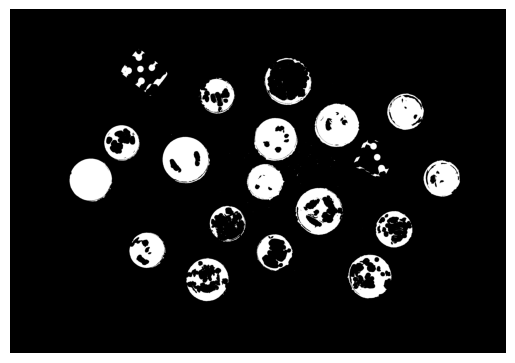

In [85]:
#umbralado
ret, mask_thresh = cv2.threshold(mask, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

plt.imshow(mask_thresh, cmap='gray')
plt.axis('off')
plt.show()

In [86]:
# componenes conectadas
(num_labels, labels, stats, centroids) = cv2.connectedComponentsWithStats(
    mask_thresh, 8, cv2.CV_32S
) 

output_image = img_color.copy()
objetos_reales = 0

for i in range(1, num_labels): # Empezamos en 1 para saltar el fondo
    area = stats[i, cv2.CC_STAT_AREA]
    
    # filtramos objetos muy pequeños (ruido)
    if area < 5000: 
        continue
    
    objetos_reales += 1
    x = stats[i, cv2.CC_STAT_LEFT]
    y = stats[i, cv2.CC_STAT_TOP]
    w = stats[i, cv2.CC_STAT_WIDTH]
    h = stats[i, cv2.CC_STAT_HEIGHT]
    
    cv2.rectangle(output_image, (x, y), (x + w, y + h), (0, 255, 0), 2)
    (cX, cY) = centroids[i] 
    cv2.putText(output_image, str(i), (int(cX) - 10, int(cY)), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 0, 255), 2)

print(f"Se encontraron {objetos_reales} objetos.")

Se encontraron 18 objetos.


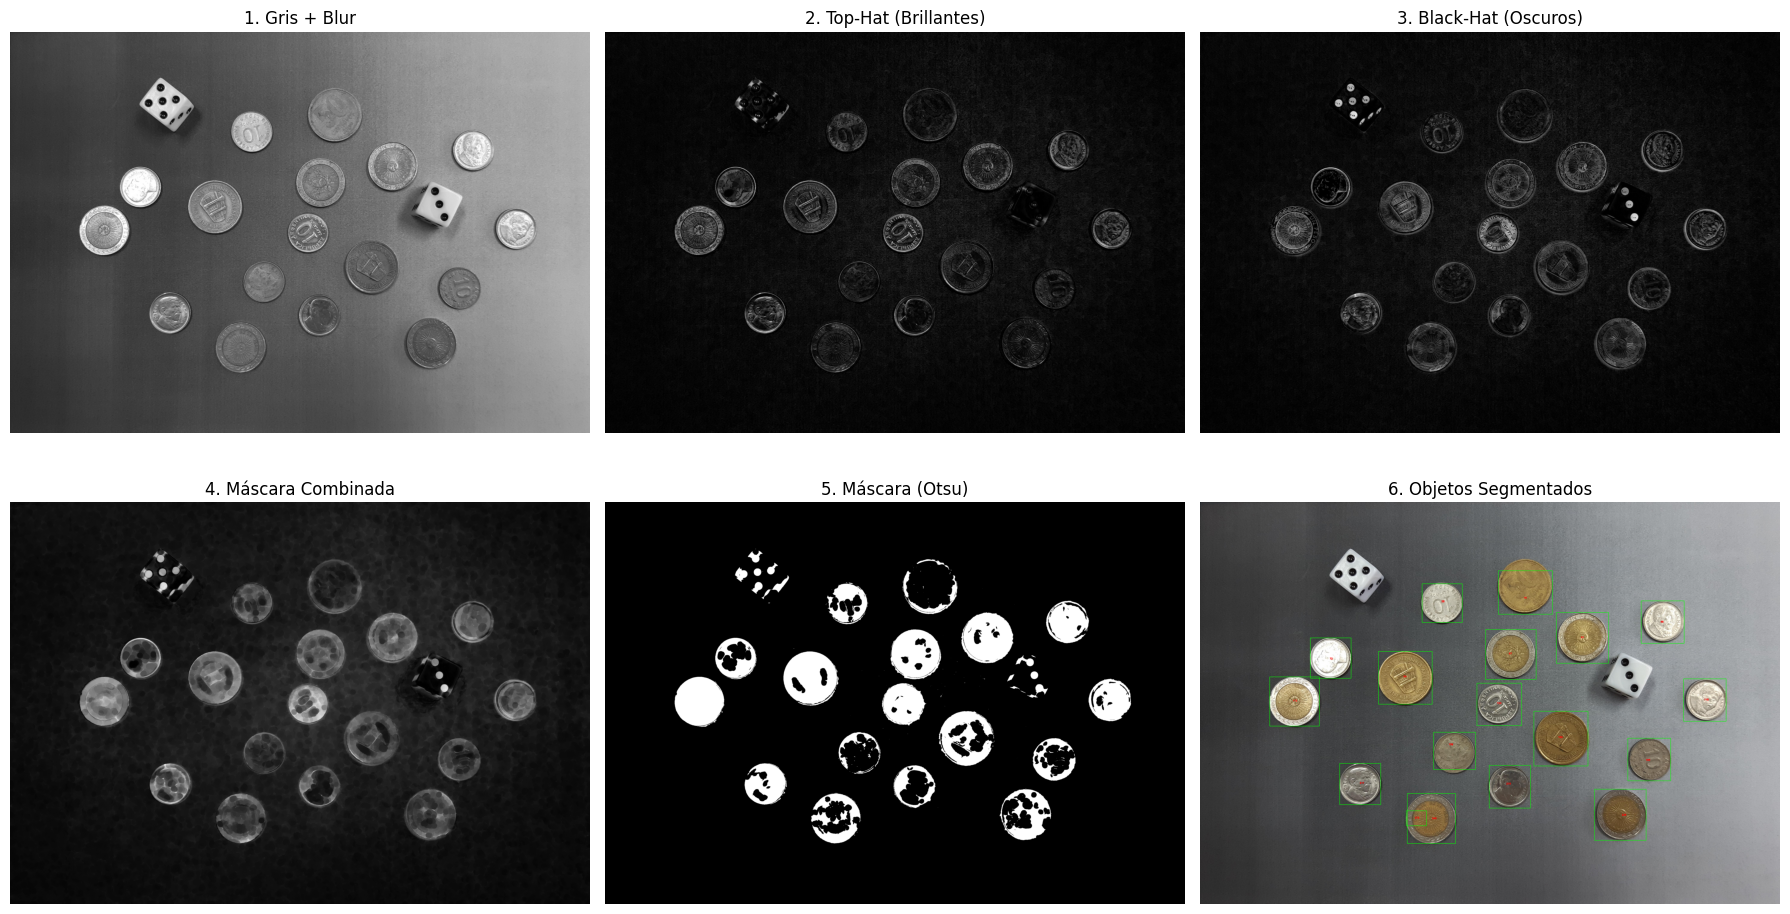

In [87]:
plt.figure(figsize=(18, 10))

plt.subplot(2, 3, 1)
plt.imshow(gray_blur, cmap='gray')
plt.title('1. Gris + Blur')
plt.axis('off')

plt.subplot(2, 3, 2)
plt.imshow(tophat, cmap='gray')
plt.title('2. Top-Hat (Brillantes)')
plt.axis('off')

plt.subplot(2, 3, 3)
plt.imshow(blackhat, cmap='gray')
plt.title('3. Black-Hat (Oscuros)')
plt.axis('off')

plt.subplot(2, 3, 4)
plt.imshow(mask, cmap='gray')
plt.title('4. Máscara Combinada')
plt.axis('off')

plt.subplot(2, 3, 5)
plt.imshow(mask_thresh, cmap='gray')
plt.title('5. Máscara (Otsu)')
plt.axis('off')

plt.subplot(2, 3, 6)
plt.imshow(cv2.cvtColor(output_image, cv2.COLOR_BGR2RGB))
plt.title('6. Objetos Segmentados')
plt.axis('off')

plt.tight_layout()
plt.show()